In [2]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
import equinox as eqx
import esm
import esm2quinox
import jax.random as jr

import jax.numpy as jnp
import numpy as np
import torch
from model_equinox import jax_predictor
from model_torch import StrippedPredictor
from transformers import AutoModel
import pandas as pd

from surr_model.dataset.dataset import Dataset_PEPBI

from surr_model.functions.model import (
    stripped_PREDICTOR,
)
from surr_model.functions.training import (
    eval_step,
)
from torch.utils.data import DataLoader

from surr_model.functions.plots import linear_corr_plot, linear_corr_plot_true_val
from transformers import AutoTokenizer
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

base_path = "/home/kunzj"


In [3]:
def no_tensor_collate(batch):
    return batch


class Dataset_PEPBI_torch:
    def __init__(self, transform, columns, data_path) -> None:
        """
        columns (List):
            0 ~ sequence_prot
            1 ~ sequence_pept
            2 ~ aff_Vals - alr. scaled
        """
        self.transform = transform
        self.data = pd.read_csv(data_path)

        self.sequences_prot = self.data[columns[0]].astype(str).str.strip().tolist()
        self.sequences_pept = self.data[columns[1]].astype(str).str.strip().tolist()

        # Tokenize all sequences at once to preserve order and be more efficient
        prot_enc = transform(self.sequences_prot, padding=True, return_tensors="pt")
        pept_enc = transform(self.sequences_pept, padding=True, return_tensors="pt")

        # Store each sample as a small dict (keeps same format as per-item tokenization)
        self.sequences_prot = [
            {
                "input_ids": prot_enc["input_ids"][i].unsqueeze(0),
                "attention_mask": prot_enc["attention_mask"][i].unsqueeze(0),
            }
            for i in range(prot_enc["input_ids"].size(0))
        ]
        self.sequences_pept = [
            {
                "input_ids": pept_enc["input_ids"][i].unsqueeze(0),
                "attention_mask": pept_enc["attention_mask"][i].unsqueeze(0),
            }
            for i in range(pept_enc["input_ids"].size(0))
        ]

        self.aff_Vals = np.array(self.data[columns[2]], dtype="f")
        self.max_seq_prot = 0
        self.max_seq_pept = 0

        for seq in self.sequences_prot:
            if self.max_seq_prot < len(seq):
                self.max_seq_prot = len(seq)

        for seq in self.sequences_pept:
            if self.max_seq_pept < len(seq):
                self.max_seq_pept = len(seq)

    def __len__(self):
        return len(self.sequences_pept)

    def __getitem__(self, idx):
        affVal = self.aff_Vals[idx]

        # protein
        seq = self.sequences_prot[idx]
        # if self.transform:
        #     padd_len = self.max_seq_prot - len(seq)
        #     seq = self.transform(seq + "." * padd_len, return_tensors='pt')

        seq_prot = seq

        # peptide
        seq = self.sequences_pept[idx]
        # if self.transform:
        #     padd_len = self.max_seq_pept - len(seq)
        #     seq = self.transform(seq + "." * padd_len, return_tensors='pt')

        #     # seq_pept_id = seq['input_ids']
        #     # seq_pept_att_mask = seq['attention_mask']

        seq_pept = seq

        return seq_prot, seq_pept, affVal

In [4]:
# class Dataset_PEPBI_jax:
#     def __init__(self, transform, columns, data_path) -> None:
#         """
#         columns (List):
#             0 ~ sequence_prot
#             1 ~ sequence_pept
#             2 ~ aff_Vals - alr. scaled
#         """
#         self.data = pd.read_csv(data_path)

#         self.sequences_prot = self.data[columns[0]].tolist()
#         self.sequences_prot = [x.strip() for x in self.sequences_prot]
#         #self.sequences_prot = [x.split("-")[0] for x in self.sequences_prot]
#         self.sequences_pept = self.data[columns[1]].tolist()
#         self.sequences_pept = [x.strip() for x in self.sequences_pept]
#         self.aff_Vals = np.array(self.data[columns[2]])
#         self.transform = transform
#         self.max_seq_prot = 0
#         self.max_seq_pept = 0

#         for seq in self.sequences_prot:
#             if self.max_seq_prot < len(seq):
#                 self.max_seq_prot = len(seq)

#         for seq in self.sequences_pept:
#             if self.max_seq_pept < len(seq):
#                 self.max_seq_pept = len(seq)

#     def __len__(self):
#         return len(self.sequences_pept)

#     def __getitem__(self, idx):
#         affVal = self.aff_Vals[idx]

#         # protein
#         seq = self.sequences_prot[idx]
#         if self.transform:
#             padd_len = self.max_seq_prot - len(seq)
#             seq = self.transform([seq + "." * padd_len])[0]

#             seq_prot = np.array(seq)

#         # peptide
#         seq = self.sequences_pept[idx]
#         if self.transform:
#             padd_len = self.max_seq_pept - len(seq)
#             seq = self.transform([seq + "." * padd_len])[0]

#             seq_pept = np.array(seq)

#         return seq_prot, seq_pept, affVal

In [5]:
jax_data = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/three_way/test.csv",
    transform=esm2quinox.tokenise,
)

jax_loader = DataLoader(jax_data, batch_size=1)

torch_data = Dataset_PEPBI_torch(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/three_way/test.csv",
    transform=AutoTokenizer.from_pretrained(
        "facebook/esm2_t30_150M_UR50D", local_files_only=True
    ),
)

torch_loader = DataLoader(torch_data, batch_size=1, collate_fn=no_tensor_collate)

equinox model conversion

In [6]:
model_key, call_key = jr.split(jr.PRNGKey(1), 2)

# initializing models
model_esm2_torch_prot, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2_torch_pept, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2_prot = esm2quinox.from_torch(model_esm2_torch_prot)
model_esm2_pept = esm2quinox.from_torch(model_esm2_torch_pept)
model_aff = jax_predictor(
    model_prot=model_esm2_prot, model_pept=model_esm2_pept, key=model_key
)

# set to inference mode
inference_model = eqx.nn.inference_mode(model_aff)
# inference_model = eqx.Partial(inference_model, state=model_state)

# load best inference pretrained model
best_model_aff = eqx.tree_deserialise_leaves(
    "/home/kunzj/BindCraft_uva_internship/surr_model/pytorch_implementation/models/equinox/model_affinity_ppi_test.eqx",
    inference_model,
)

torch model alone

In [7]:
model_path = "model_30"
model_training = "first_training"
model_esm2_prot = AutoModel.from_pretrained(
    "facebook/esm2_t30_150M_UR50D", local_files_only=True
)
model_esm2_pept = AutoModel.from_pretrained(
    "facebook/esm2_t30_150M_UR50D", local_files_only=True
)
model_torch = StrippedPredictor(model_esm2_prot, model_esm2_pept)


model_torch.load_state_dict(
    torch.load(
        f"/home/kunzj/BindCraft_uva_internship/surr_model/pytorch_implementation/models/{model_training}/{model_path}.pt",
        weights_only=True,
    )
)

model_torch.esm2_prot = model_torch.esm2_prot.merge_and_unload()
model_torch.esm2_pept = model_torch.esm2_pept.merge_and_unload()

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 128,160 || all params: 148,267,001 || trainable%: 0.0864
trainable params: 128,160 || all params: 148,267,001 || trainable%: 0.0864


equinox model alone training without conversion

In [8]:
model_key, call_key = jr.split(jr.PRNGKey(1), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)

model_aff = stripped_PREDICTOR(model=model_esm2, key=model_key)

best_model = eqx.tree_deserialise_leaves(
    "/home/kunzj/BindCraft_uva_internship/surr_model/training_results_jax/model_ppi_last_epoch.eqx",
    model_aff,
)
test_key_init = jr.PRNGKey(1)
inference_model = eqx.nn.inference_mode(best_model)


equinox alone test

In [9]:
test_loss_list_eq_alone = []
pred_y_list_eq_alone = []
y_val_list_eq_alone = []

for entry, (x_prot, x_pept, y_val) in enumerate(jax_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot, x_pept, y_val, test_key)
    test_loss_list_eq_alone.append(test_loss.item())
    pred_y_list_eq_alone.append(pred_y.item())
    y_val_list_eq_alone.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )

results_eq_alone = {
    "test_loss_list": test_loss_list_eq_alone,
    "pred_y_list": pred_y_list_eq_alone,
    "y_val_list": y_val_list_eq_alone,
}

2026-02-01 18:05:14.896885: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-02-01 18:05:14.897394: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


[Entry 1] , Test Loss: 0.005, Predicted Y: -0.386, , True Y: -0.315
[Entry 2] , Test Loss: 0.030, Predicted Y: -0.467, , True Y: -0.641
[Entry 3] , Test Loss: 0.003, Predicted Y: -0.510, , True Y: -0.452
[Entry 4] , Test Loss: 0.042, Predicted Y: -0.424, , True Y: -0.220
[Entry 5] , Test Loss: 0.062, Predicted Y: -0.456, , True Y: -0.207
[Entry 6] , Test Loss: 0.015, Predicted Y: -0.378, , True Y: -0.254
[Entry 7] , Test Loss: 0.105, Predicted Y: -0.086, , True Y: 0.237
[Entry 8] , Test Loss: 0.241, Predicted Y: -0.571, , True Y: -0.080
[Entry 9] , Test Loss: 0.294, Predicted Y: -0.043, , True Y: -0.585
[Entry 10] , Test Loss: 0.155, Predicted Y: -0.412, , True Y: -0.018
[Entry 11] , Test Loss: 0.022, Predicted Y: -0.259, , True Y: -0.111
[Entry 12] , Test Loss: 0.000, Predicted Y: -0.436, , True Y: -0.438
[Entry 13] , Test Loss: 0.051, Predicted Y: -0.283, , True Y: -0.510
[Entry 14] , Test Loss: 0.117, Predicted Y: -0.165, , True Y: 0.178
[Entry 15] , Test Loss: 0.257, Predicted Y: -

equinox conversion test

In [10]:
test_key_init = jr.PRNGKey(1)


test_loss_list_eq_conv = []
pred_y_list_eq_conv = []
y_val_list_eq_conv = []

for entry, (x_prot, x_pept, y_val) in enumerate(jax_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(best_model_aff, x_prot, x_pept, y_val, test_key)
    test_loss_list_eq_conv.append(test_loss.item())
    pred_y_list_eq_conv.append(pred_y.item())
    y_val_list_eq_conv.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss.item():.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )

results_eq_conv = {
    "test_loss_list": test_loss_list_eq_conv,
    "pred_y_list": pred_y_list_eq_conv,
    "y_val_list": y_val_list_eq_conv,
}

[Entry 1] , Test Loss: 0.001, Predicted Y: -0.285, , True Y: -0.315
[Entry 2] , Test Loss: 0.100, Predicted Y: -0.324, , True Y: -0.641
[Entry 3] , Test Loss: 0.004, Predicted Y: -0.519, , True Y: -0.452
[Entry 4] , Test Loss: 0.066, Predicted Y: -0.477, , True Y: -0.220
[Entry 5] , Test Loss: 0.004, Predicted Y: -0.146, , True Y: -0.207
[Entry 6] , Test Loss: 0.015, Predicted Y: -0.130, , True Y: -0.254
[Entry 7] , Test Loss: 0.379, Predicted Y: -0.379, , True Y: 0.237
[Entry 8] , Test Loss: 0.003, Predicted Y: -0.138, , True Y: -0.080
[Entry 9] , Test Loss: 0.205, Predicted Y: -0.133, , True Y: -0.585
[Entry 10] , Test Loss: 0.006, Predicted Y: -0.098, , True Y: -0.018
[Entry 11] , Test Loss: 0.003, Predicted Y: -0.163, , True Y: -0.111
[Entry 12] , Test Loss: 0.030, Predicted Y: -0.265, , True Y: -0.438
[Entry 13] , Test Loss: 0.224, Predicted Y: -0.036, , True Y: -0.510
[Entry 14] , Test Loss: 0.223, Predicted Y: -0.294, , True Y: 0.178
[Entry 15] , Test Loss: 0.185, Predicted Y: -

torch test loop

In [11]:
loss_fn = torch.nn.MSELoss()
for param in model_torch.esm2_pept.parameters():
    param.requires_grad_(False)

for param in model_torch.esm2_prot.parameters():
    param.requires_grad_(False)

device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device)
model_torch.to(device)

model_torch.eval()
running_vloss = 0
results_torch = {"test_loss_list": [], "pred_y_list": [], "y_val_list": []}
with torch.no_grad():
    for i, val_data in enumerate(torch_loader):
        val_prot, val_pept, val_aff_val = val_data[0]

        id_prot = val_prot["input_ids"].to("cuda")
        att_prot = val_prot["attention_mask"].to("cuda")

        id_pept = val_pept["input_ids"].to("cuda")
        att_pept = val_pept["attention_mask"].to("cuda")

        voutputs = model_torch(id_prot, att_prot, id_pept, att_pept)
        vloss = loss_fn(voutputs, torch.tensor(val_aff_val).to("cuda"))

        results_torch["pred_y_list"].append(float(val_aff_val))
        results_torch["y_val_list"].append(float(voutputs.to("cpu")))
        results_torch["test_loss_list"].append(vloss.item())
        print(f"Step Loss - {i}: {vloss.item()}")

Step Loss - 0: 0.0008592500817030668
Step Loss - 1: 0.0007129706209525466
Step Loss - 2: 0.0029169260524213314
Step Loss - 3: 0.0263801459223032
Step Loss - 4: 0.004005810711532831
Step Loss - 5: 0.04317758232355118
Step Loss - 6: 0.5096715688705444
Step Loss - 7: 0.0011245919158682227
Step Loss - 8: 0.48972171545028687
Step Loss - 9: 0.007255942095071077
Step Loss - 10: 0.00022674727370031178
Step Loss - 11: 0.010412877425551414
Step Loss - 12: 0.2610500156879425
Step Loss - 13: 0.2778416574001312
Step Loss - 14: 0.20287416875362396
Step Loss - 15: 0.008526861667633057
Step Loss - 16: 0.015456411056220531
Step Loss - 17: 0.0005083634750917554
Step Loss - 18: 0.0002991447108797729
Step Loss - 19: 0.04232930392026901
Step Loss - 20: 0.014549403451383114
Step Loss - 21: 0.17130295932292938
Step Loss - 22: 0.27491384744644165
Step Loss - 23: 0.19896909594535828
Step Loss - 24: 0.010415316559374332
Step Loss - 25: 0.015803325921297073
Step Loss - 26: 0.014672813937067986
Step Loss - 27: 0.

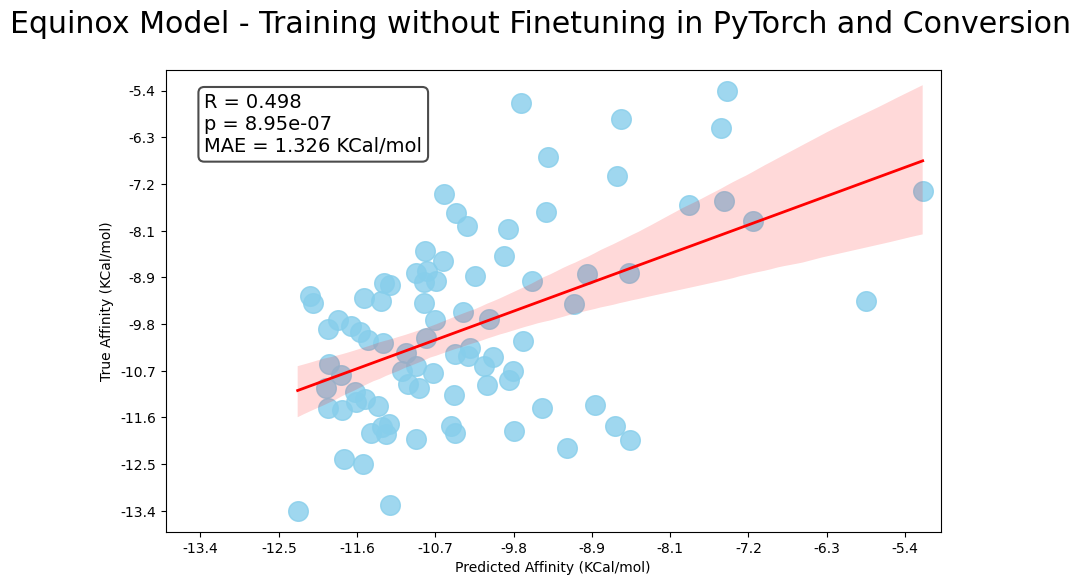

In [15]:
fixed(
    results_eq_alone["pred_y_list"],
    results_eq_alone["y_val_list"],
    x_label="Predicted Affinity (KCal/mol)",
    y_label="True Affinity (KCal/mol)",
    title="Equinox Model - Training without Finetuning in PyTorch and Conversion",
)

In [16]:
from scipy.stats import pearsonr
import sklearn.metrics as metrics
import seaborn as sns
import matplotlib.pyplot as plt


In [17]:
def rev_min_max_func(scaled_val):
    raw_train_ppi = pd.read_csv(
        "/home/kunzj/BindCraft_uva_internship/data/ppi_affinity_dataset/raw/training.csv"
    )
    max_val = np.max(raw_train_ppi["delta_G"])
    min_val = np.min(raw_train_ppi["delta_G"])
    # og_val = (scaled_val*(max_val - min_val)) + min_val

    og_val = ((scaled_val + 1) * (max_val - min_val) / 2) + min_val
    return og_val


def fixed(value_x: list, value_y: list, x_label: str, y_label: str, title: str) -> None:
    """
    both dictionary needs to be sorted in the same way
    """
    y_values = [rev_min_max_func(x) / 4.184 for x in list(value_y)]
    x_values = [rev_min_max_func(x) / 4.184 for x in list(value_x)]

    # Compute correlation
    r, p_value = pearsonr(y_values, x_values)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.set_context("talk")

    sns.regplot(
        x=x_values,
        y=y_values,
        ax=ax,
        scatter_kws={"s": 200, "alpha": 0.8},
        line_kws={"color": "red", "lw": 2},
        color="skyblue",
    )

    # Labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    # ax.set_title("Correlation between Energy and Color variable")
    y_min, y_max = min(y_values), max(y_values)
    ax.set_ylim(y_min - (y_max - y_min) * 0.05, y_max + (y_max - y_min) * 0.05)
    ax.set_yticks(np.round(np.linspace(y_min, y_max, num=10), 2))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.set_xlim(y_min - (y_max - y_min) * 0.05, y_max + (y_max - y_min) * 0.05)
    ax.set_xticks(np.round(np.linspace(y_min, y_max, num=10), 2))
    # ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    # Annotate correlation coefficient on the plot
    ax.text(
        0.05,
        0.95,
        f"R = {r:.3f}\np = {p_value:.2e}\nMAE = {metrics.mean_absolute_error(y_values, x_values):.3f} KCal/mol",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )
    fig.suptitle(title)
    plt.show()

In [18]:
metrics.mean_absolute_error(
    results_eq_conv["y_val_list"], results_eq_conv["pred_y_list"]
)

0.21841195606808553

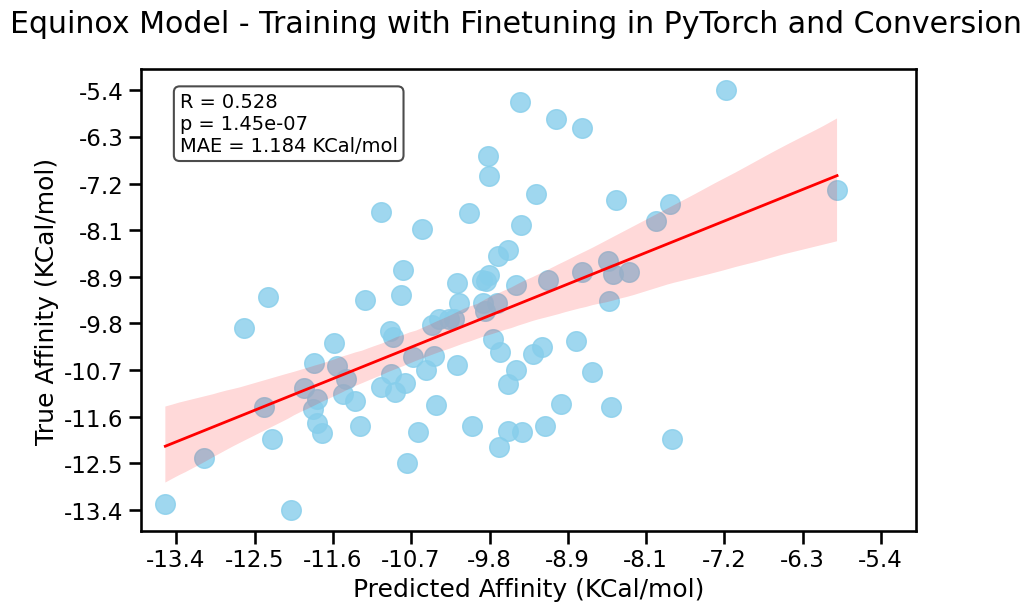

In [19]:
fixed(
    results_eq_conv["pred_y_list"],
    results_eq_conv["y_val_list"],
    x_label="Predicted Affinity (KCal/mol)",
    y_label="True Affinity (KCal/mol)",
    title="Equinox Model - Training with Finetuning in PyTorch and Conversion",
)

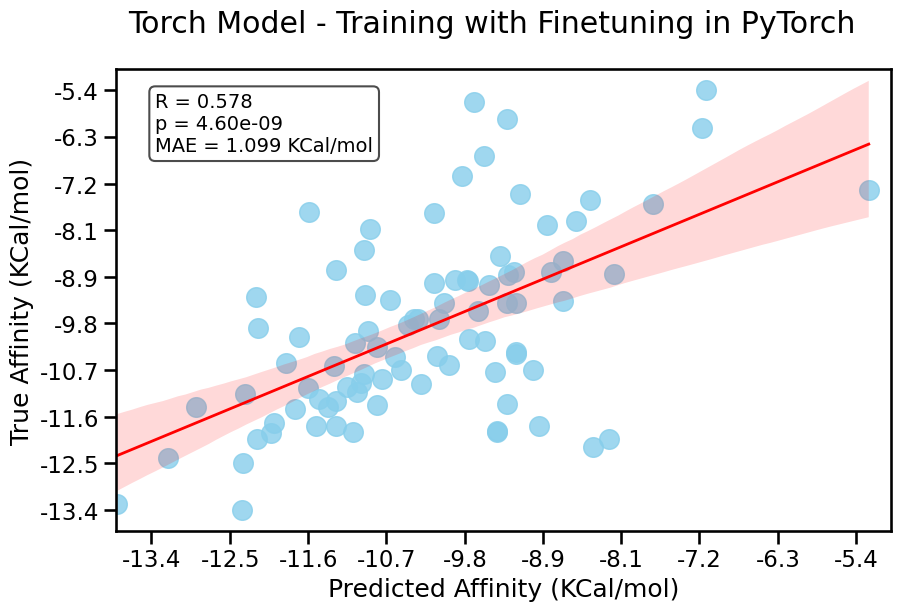

In [20]:
fixed(
    results_torch["y_val_list"],
    results_torch["pred_y_list"],
    x_label="Predicted Affinity (KCal/mol)",
    y_label="True Affinity (KCal/mol)",
    title="Torch Model - Training with Finetuning in PyTorch",
)

In [21]:
trained_dic = {
    'torch_pred': results_torch["y_val_list"],
    'equinox_conv_pred': results_eq_conv["pred_y_list"],
    'equinox_raw_pred': results_eq_alone["pred_y_list"],
    'true_val':results_torch["pred_y_list"] 
}
df = pd.DataFrame(trained_dic)


df.to_csv('/home/kunzj/report/data/surr_model_training.csv')

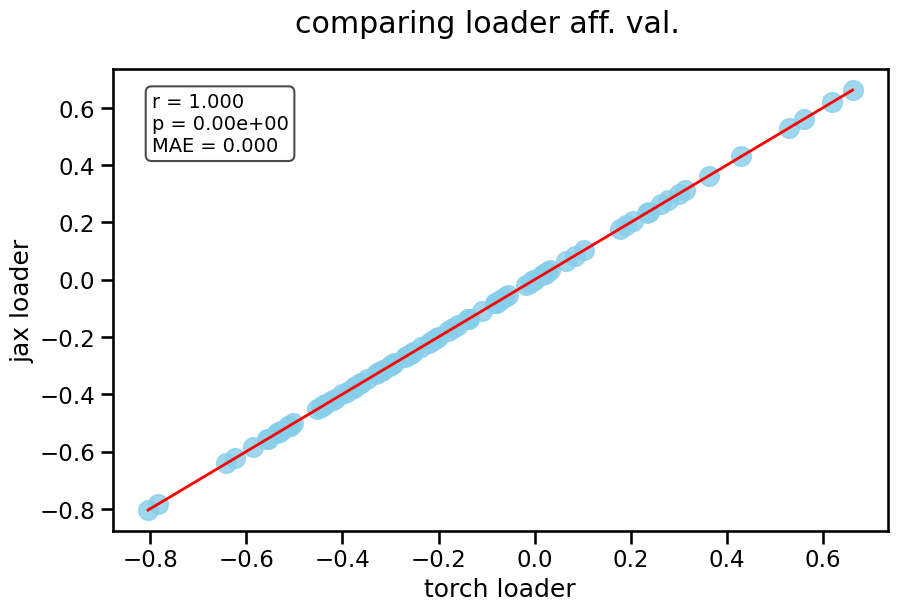

In [22]:
linear_corr_plot(
    list(torch_data.aff_Vals),
    list(jax_data.aff_Vals),
    x_label="torch loader",
    y_label="jax loader",
    title="comparing loader aff. val.",
)

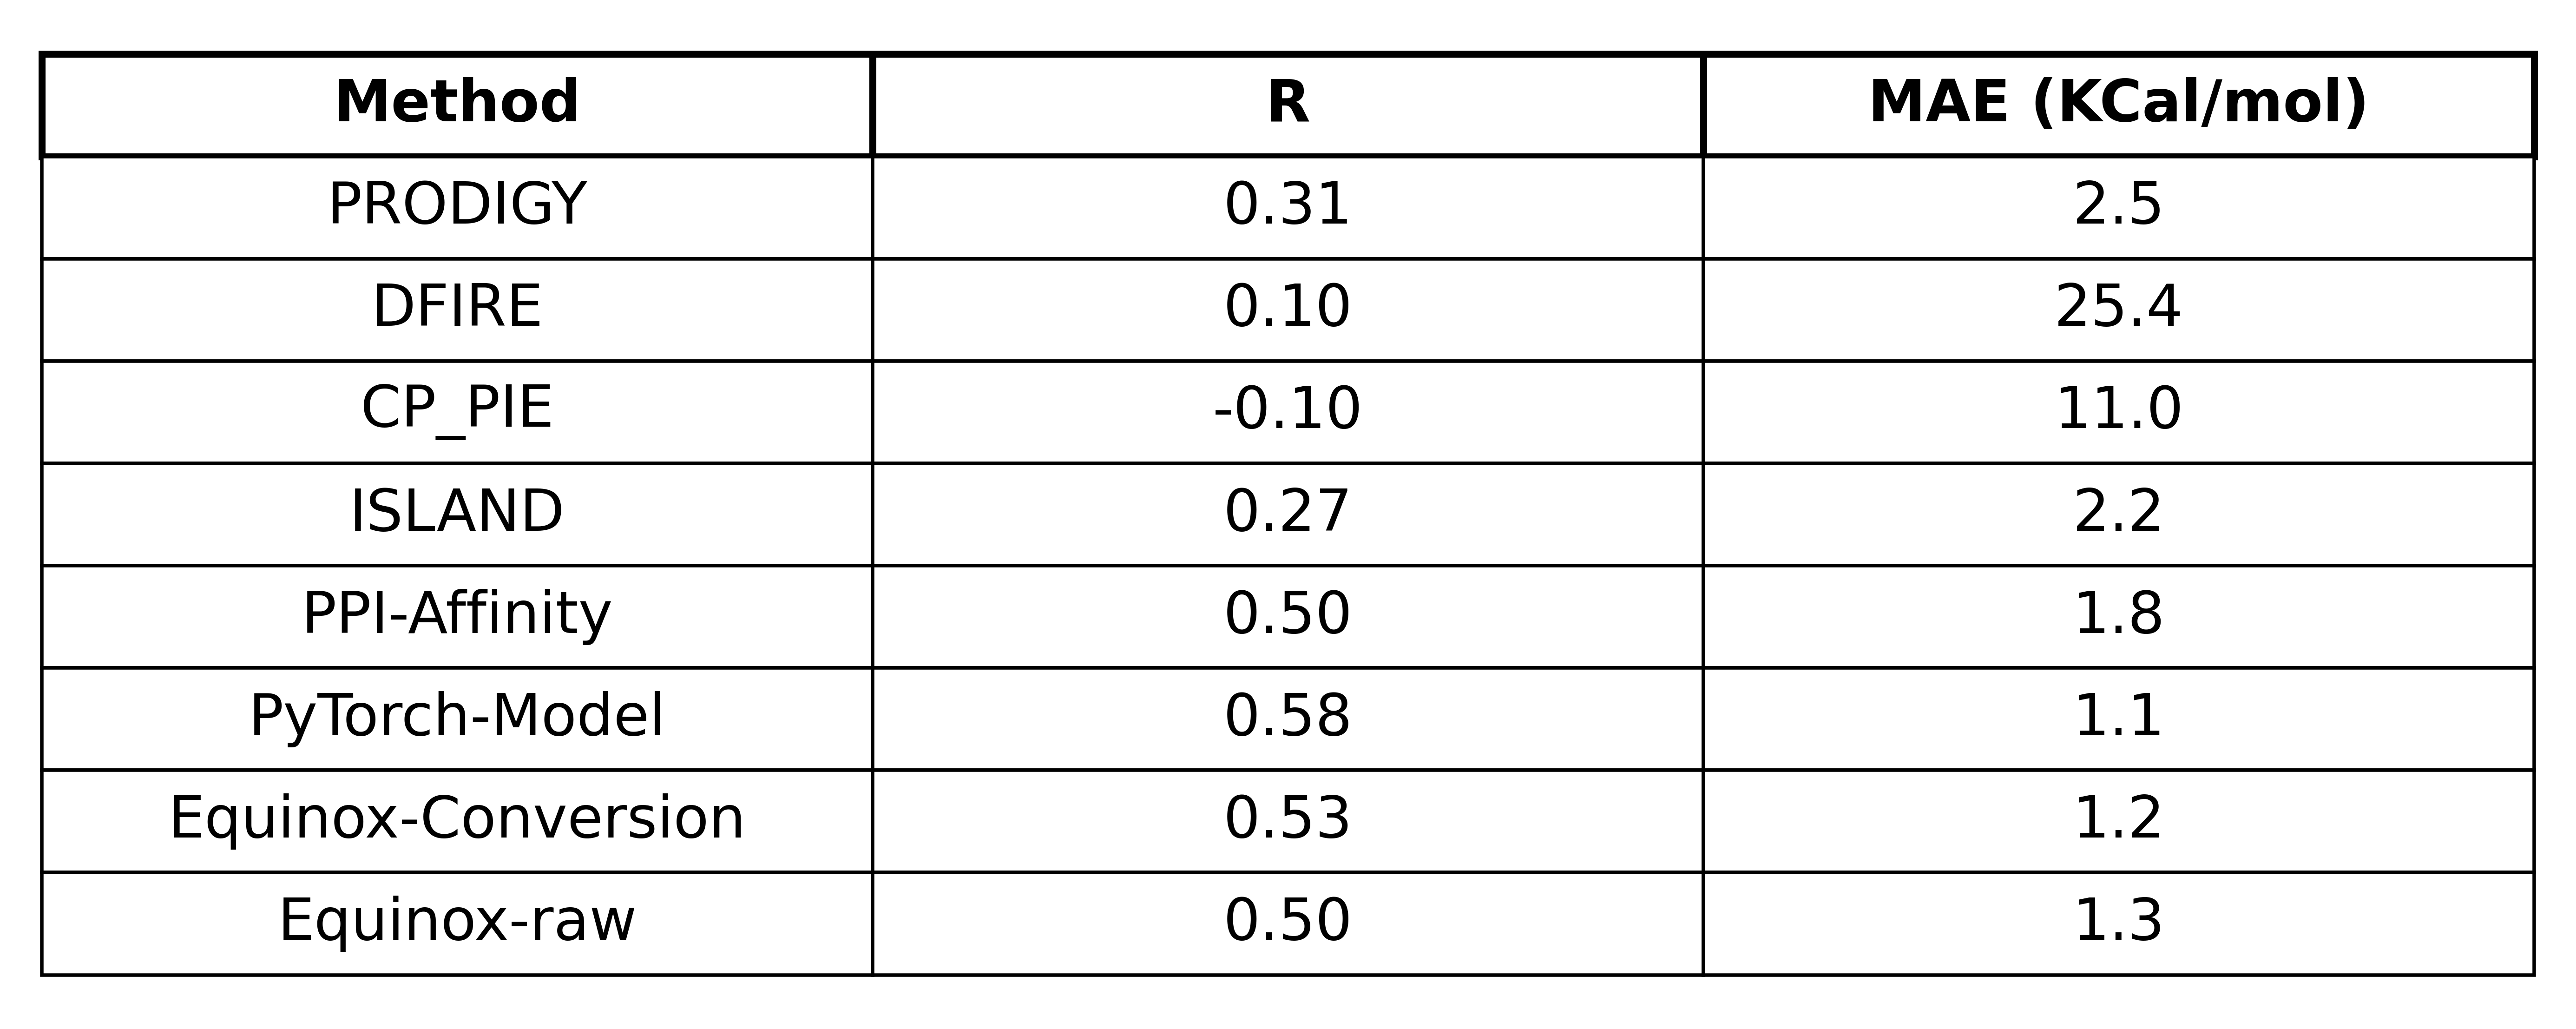

Method,R,MAE (KCal/mol)
PRODIGY,0.31,2.5
DFIRE,0.10,25.4
CP_PIE,-0.10,11.0
ISLAND,0.27,2.2
PPI-Affinity,0.50,1.8
PyTorch-Model,0.58,1.1
Equinox-Conversion,0.53,1.2
Equinox-raw,0.50,1.3


In [25]:
KCAL_TO_KJ = 4.184


def make_testset2_table(new_method=None, new_R=None, new_MAE_kcal=None, save_path=None):
    """
    Create a publication-style table figure for Test Set 2.

    Parameters
    ----------
    new_method : str, optional
        Name of an additional method to add.
    new_R : float, optional
        Correlation coefficient (R) for the new method.
    new_MAE_kcal : float, optional
        MAE in kcal/mol for the new method.
    save_path : str, optional
        If provided, saves the figure (e.g., 'table_testset2.pdf').
    """

    # Base data (Test Set 2 only)
    data = {
        "Method": [
            "PRODIGY",
            "DFIRE",
            "CP_PIE",
            "ISLAND",
            "PPI-Affinity",
            "PyTorch-Model",
            "Equinox-Conversion",
            "Equinox-raw",
            
        ],
        "R": [0.31, 0.10, -0.10, 0.27, 0.50,0.58,  0.53,0.50],
        "MAE (KCal/mol)": [2.5, 25.4, 11.0, 2.2, 1.8, 1.1, 1.2, 1.3],
    }

    df = pd.DataFrame(data)



    # Optional: add one new value
    if new_method is not None:
        df.loc[len(df)] = [new_method, new_R, new_MAE_kcal]

    # Format numbers for publication
    df["R"] = df["R"].map(lambda x: f"{x:.2f}")
    df["MAE (KCal/mol)"] = df["MAE (KCal/mol)"].map(lambda x: f"{x:.1f}")

    # Create figure
    fig, ax = plt.subplots(figsize=(6.5, 2.8),dpi=900)
    ax.axis("off")
    
    styler = (
        df.style
        .set_properties(**{
            "text-align": "center",
            "font-size": "12pt"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("border-bottom", "2px solid black")
                ]
            },
            {
                "selector": "td",
                "props": [("border-bottom", "1px solid #DDDDDD")]
            },
        ])
        .hide(axis="index")
        .background_gradient(
            subset=["R"],
            cmap="Greens"
        )
        .background_gradient(
            subset=["MAE (KCal/mol)"],
            cmap="Reds_r"
        )
    )    

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )

    # Styling for paper
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)

    # Header styling
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_linewidth(1.2)
        else:
            cell.set_linewidth(0.6)

    #ax.set_title("Performance on PPI Test Set (MAE in kJ/mol)", fontsize=11, pad=10)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, styler


# -------------------------
# Example usage:
# -------------------------
fig,styler = make_testset2_table()
plt.show()
styler